In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error

In [2]:
# get detials of the files 
mv = pd.read_csv("movielens.csv")
ml = pd.read_csv("movielens_val_indices.csv") 
md = pd.read_pickle("movie_map.pkl")

In [21]:
mv.head(10)

,userId,movieId,rating,timestamp,title,genres
0,0,0,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,0,2,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,0,4,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,0,23,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,0,25,5.0,964982931,Usual Suspects; The (1995),Crime|Mystery|Thriller
5,0,31,3.0,964982400,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
6,0,35,4.0,964982176,Braveheart (1995),Action|Drama|War
7,0,42,5.0,964984041,Rob Roy (1995),Action|Drama|Romance|War
8,0,47,5.0,964983650,Desperado (1995),Action|Romance|Western
9,0,61,5.0,964981208,Billy Madison (1995),Comedy


In [3]:

mv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62518 entries, 0 to 62517
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     62518 non-null  int64  
 1   movieId    62518 non-null  int64  
 2   rating     62518 non-null  float64
 3   timestamp  62518 non-null  int64  
 4   title      62518 non-null  object 
 5   genres     62518 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 2.9+ MB


In [4]:
mv.shape

(62518, 6)

In [5]:
ml.head(10) 

,row_inds,col_inds
0,541,743
1,306,387
2,153,958
3,554,649
4,253,719
5,132,89
6,474,1040
7,308,611
8,311,143
9,289,216


In [6]:
ml.shape 

(6252, 2)

In [7]:
print(type(md))
print(len(md))

<class 'dict'>
1050


In [10]:
A_mv = mv.pivot_table(
    index="userId", 
    columns="movieId", 
    values="rating", 
    fill_value= 0 
)


print("A shape:", A_mv.shape)

A shape: (610, 1050)


In [12]:
A = A_mv.to_numpy(dtype=np.float32)

print("A shape:", A.shape)
print("A nonzeros:", np.count_nonzero(A))
print("A sum:", float(A.sum()))

rows = ml["row_inds"].to_numpy(dtype=int)
cols = ml["col_inds"].to_numpy(dtype=int)

y_val_true = A[rows, cols].copy()

print("y_val_true shape:", y_val_true.shape)
print("y_val_true first 10:", y_val_true[:10])
print("y_val_true last 10:", y_val_true[-10:])

A_fit = A.copy()
A_fit[rows, cols] = 0.0

print("All validation entries zeroed in A_fit?",
      bool(np.all(A_fit[rows, cols] == 0.0)))

print("A_fit sum:", float(A_fit.sum()))

A shape: (610, 1050)
A nonzeros: 62518
A sum: 227818.5
y_val_true shape: (6252,)
y_val_true first 10: [4.  2.  5.  3.  4.5 4.  5.  3.5 5.  5. ]
y_val_true last 10: [2.5 4.5 3.  3.  3.5 4.  3.  3.  3.  4. ]
All validation entries zeroed in A_fit? True
A_fit sum: 205049.0


In [16]:
A_fill0 = A_fit.copy()

A_fillmean = A_fit.copy().astype(np.float32)

nonzero_mask = (A_fit != 0)
global_mean = A_fit[nonzero_mask].mean() if np.any(nonzero_mask) else 0.0
print("global_mean =", float(global_mean))

user_means = np.zeros(A_fit.shape[0], dtype=np.float32)

for u in range(A_fit.shape[0]):
    row = A_fit[u, :]
    nz = row != 0
    if np.any(nz):
        user_means[u] = row[nz].mean()
    else:
        user_means[u] = global_mean


for u in range(A_fillmean.shape[0]):
    zero_pos = (A_fillmean[u, :] == 0)
    A_fillmean[u, zero_pos] = user_means[u]


print("sample user_means:", user_means[:5])
print("number of zeros after mean-fill:", int(np.sum(A_fillmean == 0)))


global_mean = 3.6442790031433105
sample user_means: [4.4       3.909091  1.7368422 3.5526316 3.5675676]
number of zeros after mean-fill: 0


A_fill0 shape: (610, 1050)
A_fillmean shape: (610, 1050)
y_val_true shape: (6252,)

Computing SVD for A_fill0 ...
Computing SVD for A_fillmean ...

--- k = 5 ---
RMSE (SVD + fill0): 2.670011617942422
RMSE (SVD + fillmean): 0.8687372536032901

--- k = 10 ---
RMSE (SVD + fill0): 2.5919538966364386
RMSE (SVD + fillmean): 0.8659155512946265

--- k = 15 ---
RMSE (SVD + fill0): 2.5785719975303683
RMSE (SVD + fillmean): 0.8676625574378322

--- k = 20 ---
RMSE (SVD + fill0): 2.6104966910706047
RMSE (SVD + fillmean): 0.8699660935316996

--- k = 30 ---
RMSE (SVD + fill0): 2.705525649747729
RMSE (SVD + fillmean): 0.8791882888943352

--- k = 40 ---
RMSE (SVD + fill0): 2.8107551248366787
RMSE (SVD + fillmean): 0.8842469099043114

--- k = 60 ---
RMSE (SVD + fill0): 3.005816067091766
RMSE (SVD + fillmean): 0.8917010983982147

--- k = 80 ---
RMSE (SVD + fill0): 3.1665496469927827
RMSE (SVD + fillmean): 0.8982995964030701

--- k = 100 ---
RMSE (SVD + fill0): 3.2936754656181506
RMSE (SVD + fillmean): 0.

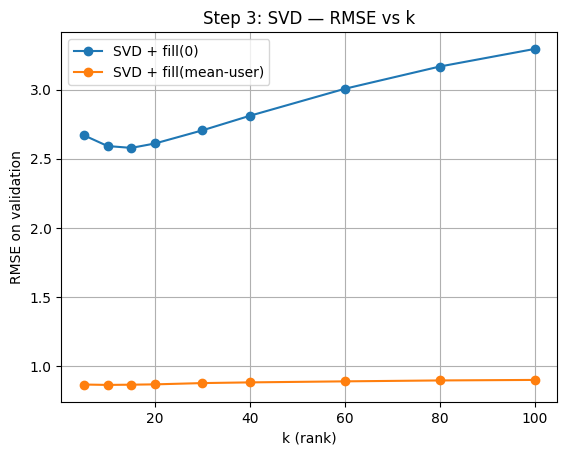


Summary:
k=  5 | RMSE fill0=2.6700 | RMSE fillmean=0.8687
k= 10 | RMSE fill0=2.5920 | RMSE fillmean=0.8659
k= 15 | RMSE fill0=2.5786 | RMSE fillmean=0.8677
k= 20 | RMSE fill0=2.6105 | RMSE fillmean=0.8700
k= 30 | RMSE fill0=2.7055 | RMSE fillmean=0.8792
k= 40 | RMSE fill0=2.8108 | RMSE fillmean=0.8842
k= 60 | RMSE fill0=3.0058 | RMSE fillmean=0.8917
k= 80 | RMSE fill0=3.1665 | RMSE fillmean=0.8983
k=100 | RMSE fill0=3.2937 | RMSE fillmean=0.9020


In [17]:
k_list = [5, 10, 15, 20, 30, 40, 60, 80, 100]


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) 


def reconstruct_rank_k(U, S, Vt, k):
    Uk = U[:, :k]
    Sk = S[:k]   
    Vtk = Vt[:k, :]
    X_hat = (Uk * Sk) @ Vtk
    return X_hat


A_fill0 = A_fill0.astype(np.float32)
A_fillmean = A_fillmean.astype(np.float32)
y_val_true = y_val_true.astype(np.float32)

print("A_fill0 shape:", A_fill0.shape)
print("A_fillmean shape:", A_fillmean.shape)
print("y_val_true shape:", y_val_true.shape)


print("\nComputing SVD for A_fill0 ...")
U0, S0, Vt0 = np.linalg.svd(A_fill0, full_matrices=False)

print("Computing SVD for A_fillmean ...")
Um, Sm, Vtm = np.linalg.svd(A_fillmean, full_matrices=False)

rmse_fill0 = []
rmse_fillmean = []

for k in k_list:
    print(f"\n--- k = {k} ---")

    # zero-fill
    Ahat0 = reconstruct_rank_k(U0, S0, Vt0, k)
    y_val_pred0 = Ahat0[rows, cols]
    r0 = rmse(y_val_true, y_val_pred0)
    rmse_fill0.append(r0)
    print("RMSE (SVD + fill0):", float(r0))

    # mean-fill
    Ahatm = reconstruct_rank_k(Um, Sm, Vtm, k)
    y_val_predm = Ahatm[rows, cols]
    rm = rmse(y_val_true, y_val_predm)
    rmse_fillmean.append(rm)
    print("RMSE (SVD + fillmean):", float(rm))
    
plt.figure()
plt.plot(k_list, rmse_fill0, marker="o", label="SVD + fill(0)")
plt.plot(k_list, rmse_fillmean, marker="o", label="SVD + fill(mean-user)")
plt.xlabel("k (rank)")
plt.ylabel("RMSE on validation")
plt.title("Step 3: SVD — RMSE vs k")
plt.grid(True)
plt.legend()
plt.show()

print("\nSummary:")
for i, k in enumerate(k_list):
    print(f"k={k:3d} | RMSE fill0={rmse_fill0[i]:.4f} | RMSE fillmean={rmse_fillmean[i]:.4f}")


--- PCA Step 4 | k = 5 ---
RMSE PCA(cov) + fill0: 2.6603322692086366
RMSE PCA(cov) + fillmean: 0.8688346752917665
RMSE PCA(SVD) + fill0: 2.6603322692086366
RMSE PCA(SVD) + fillmean: 0.8688346752917665

--- PCA Step 4 | k = 10 ---
RMSE PCA(cov) + fill0: 2.5901968644782447
RMSE PCA(cov) + fillmean: 0.866141917544238
RMSE PCA(SVD) + fill0: 2.590197048571256
RMSE PCA(SVD) + fillmean: 0.866141917544238

--- PCA Step 4 | k = 15 ---
RMSE PCA(cov) + fill0: 2.578147194506739
RMSE PCA(cov) + fillmean: 0.8676019657574409
RMSE PCA(SVD) + fill0: 2.578147471936864
RMSE PCA(SVD) + fillmean: 0.8676019657574409

--- PCA Step 4 | k = 20 ---
RMSE PCA(cov) + fill0: 2.6114069171394076
RMSE PCA(cov) + fillmean: 0.8700286100879218
RMSE PCA(SVD) + fill0: 2.6114069171394076
RMSE PCA(SVD) + fillmean: 0.8700286100879218

--- PCA Step 4 | k = 30 ---
RMSE PCA(cov) + fill0: 2.707113861981235
RMSE PCA(cov) + fillmean: 0.8790987609262666
RMSE PCA(SVD) + fill0: 2.7071139500523644
RMSE PCA(SVD) + fillmean: 0.879098760

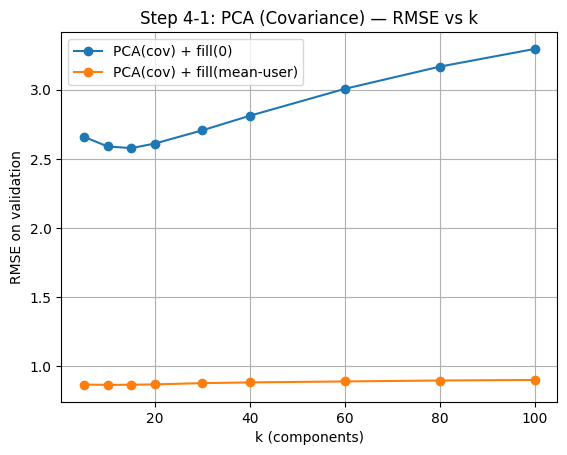

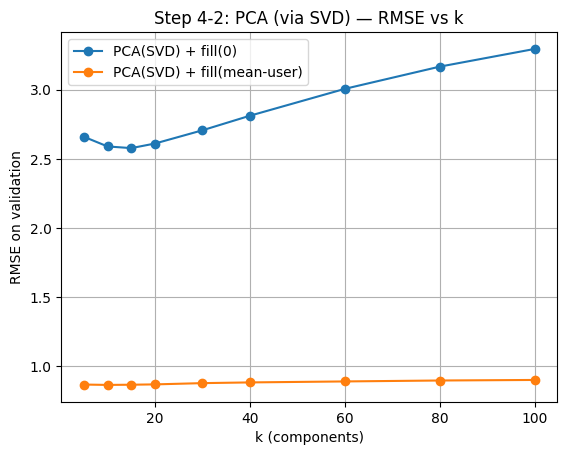

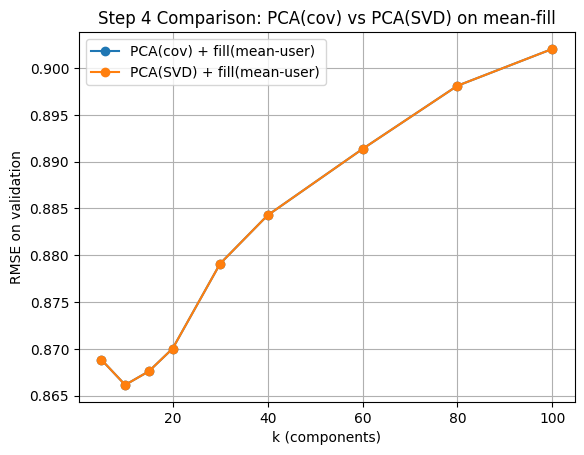


Summary table (Step 4):
k=  5 | cov0=2.6603 | covmean=0.8688 | svd0=2.6603 | svdmean=0.8688
k= 10 | cov0=2.5902 | covmean=0.8661 | svd0=2.5902 | svdmean=0.8661
k= 15 | cov0=2.5781 | covmean=0.8676 | svd0=2.5781 | svdmean=0.8676
k= 20 | cov0=2.6114 | covmean=0.8700 | svd0=2.6114 | svdmean=0.8700
k= 30 | cov0=2.7071 | covmean=0.8791 | svd0=2.7071 | svdmean=0.8791
k= 40 | cov0=2.8124 | covmean=0.8843 | svd0=2.8124 | svdmean=0.8843
k= 60 | cov0=3.0067 | covmean=0.8914 | svd0=3.0067 | svdmean=0.8914
k= 80 | cov0=3.1673 | covmean=0.8981 | svd0=3.1673 | svdmean=0.8981
k=100 | cov0=3.2952 | covmean=0.9020 | svd0=3.2952 | svdmean=0.9020


In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def center_columns(X):
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu
    return Xc, mu

def pca_cov_reconstruct(X, k):
    Xc, mu = center_columns(X)
    n_users = Xc.shape[0]

    Cov = (Xc.T @ Xc) / (n_users - 1)

    eigvals, eigvecs = np.linalg.eigh(Cov)
    idx = np.argsort(eigvals)[::-1]
    W = eigvecs[:, idx]

    Wk = W[:, :k]    

    Xc_hat = (Xc @ Wk) @ Wk.T
    X_hat = Xc_hat + mu
    return X_hat

def pca_svd_reconstruct(X, k):
    Xc, mu = center_columns(X)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

    Uk = U[:, :k]
    Sk = S[:k]
    Vtk = Vt[:k, :]

    Xc_hat = (Uk * Sk) @ Vtk
    X_hat = Xc_hat + mu
    return X_hat


k_list = [5, 10, 15, 20, 30, 40, 60, 80, 100]

A_fill0 = A_fill0.astype(np.float32)
A_fillmean = A_fillmean.astype(np.float32)
y_val_true = y_val_true.astype(np.float32)

rmse_pca_cov_fill0 = []
rmse_pca_cov_fillmean = []
rmse_pca_svd_fill0 = []
rmse_pca_svd_fillmean = []

for k in k_list:
    print(f"\n--- PCA Step 4 | k = {k} ---")

    Xhat_cov0 = pca_cov_reconstruct(A_fill0, k)
    y_pred_cov0 = Xhat_cov0[rows, cols]
    r_cov0 = rmse(y_val_true, y_pred_cov0)
    rmse_pca_cov_fill0.append(r_cov0)
    print("RMSE PCA(cov) + fill0:", float(r_cov0))

    Xhat_covm = pca_cov_reconstruct(A_fillmean, k)
    y_pred_covm = Xhat_covm[rows, cols]
    r_covm = rmse(y_val_true, y_pred_covm)
    rmse_pca_cov_fillmean.append(r_covm)
    print("RMSE PCA(cov) + fillmean:", float(r_covm))

    Xhat_svd0 = pca_svd_reconstruct(A_fill0, k)
    y_pred_svd0 = Xhat_svd0[rows, cols]
    r_svd0 = rmse(y_val_true, y_pred_svd0)
    rmse_pca_svd_fill0.append(r_svd0)
    print("RMSE PCA(SVD) + fill0:", float(r_svd0))

    Xhat_svdm = pca_svd_reconstruct(A_fillmean, k)
    y_pred_svdm = Xhat_svdm[rows, cols]
    r_svdm = rmse(y_val_true, y_pred_svdm)
    rmse_pca_svd_fillmean.append(r_svdm)
    print("RMSE PCA(SVD) + fillmean:", float(r_svdm))


plt.figure()
plt.plot(k_list, rmse_pca_cov_fill0, marker="o", label="PCA(cov) + fill(0)")
plt.plot(k_list, rmse_pca_cov_fillmean, marker="o", label="PCA(cov) + fill(mean-user)")
plt.xlabel("k (components)")
plt.ylabel("RMSE on validation")
plt.title("Step 4-1: PCA (Covariance) — RMSE vs k")
plt.grid(True)
plt.legend()
plt.show()


plt.figure()
plt.plot(k_list, rmse_pca_svd_fill0, marker="o", label="PCA(SVD) + fill(0)")
plt.plot(k_list, rmse_pca_svd_fillmean, marker="o", label="PCA(SVD) + fill(mean-user)")
plt.xlabel("k (components)")
plt.ylabel("RMSE on validation")
plt.title("Step 4-2: PCA (via SVD) — RMSE vs k")
plt.grid(True)
plt.legend()
plt.show()


plt.figure()
plt.plot(k_list, rmse_pca_cov_fillmean, marker="o", label="PCA(cov) + fill(mean-user)")
plt.plot(k_list, rmse_pca_svd_fillmean, marker="o", label="PCA(SVD) + fill(mean-user)")
plt.xlabel("k (components)")
plt.ylabel("RMSE on validation")
plt.title("Step 4 Comparison: PCA(cov) vs PCA(SVD) on mean-fill")
plt.grid(True)
plt.legend()
plt.show()

print("\nSummary table (Step 4):")
for i, k in enumerate(k_list):
    print(
        f"k={k:3d} | "
        f"cov0={rmse_pca_cov_fill0[i]:.4f} | covmean={rmse_pca_cov_fillmean[i]:.4f} | "
        f"svd0={rmse_pca_svd_fill0[i]:.4f} | svdmean={rmse_pca_svd_fillmean[i]:.4f}"
    )


In [20]:
def best_k_and_rmse(k_list, rmse_list):
    rmse_arr = np.array(rmse_list, dtype=float)
    idx = int(np.argmin(rmse_arr))          
    return int(k_list[idx]), float(rmse_arr[idx])
results = {}


results["SVD + fill(0)"] = best_k_and_rmse(k_list, rmse_fill0)
results["SVD + fill(mean-user)"] = best_k_and_rmse(k_list, rmse_fillmean)


results["PCA(cov) + fill(0)"] = best_k_and_rmse(k_list, rmse_pca_cov_fill0)
results["PCA(cov) + fill(mean-user)"] = best_k_and_rmse(k_list, rmse_pca_cov_fillmean)


results["PCA(SVD) + fill(0)"] = best_k_and_rmse(k_list, rmse_pca_svd_fill0)
results["PCA(SVD) + fill(mean-user)"] = best_k_and_rmse(k_list, rmse_pca_svd_fillmean)

print("STEP 5 — Best k (argmin RMSE) results:\n")
for name, (k_best, best_rmse) in results.items():
    print(f"{name:28s}  ->  best_k = {k_best:3d} , best_RMSE = {best_rmse:.6f}")


best_model_name = min(results.keys(), key=lambda key: results[key][1])
overall_k_best, overall_best_rmse = results[best_model_name]

print("\nOVERALL BEST MODEL:")
print(f"{best_model_name}  ->  best_k = {overall_k_best} , best_RMSE = {overall_best_rmse:.6f}")


STEP 5 — Best k (argmin RMSE) results:

SVD + fill(0)                 ->  best_k =  15 , best_RMSE = 2.578572
SVD + fill(mean-user)         ->  best_k =  10 , best_RMSE = 0.865916
PCA(cov) + fill(0)            ->  best_k =  15 , best_RMSE = 2.578147
PCA(cov) + fill(mean-user)    ->  best_k =  10 , best_RMSE = 0.866142
PCA(SVD) + fill(0)            ->  best_k =  15 , best_RMSE = 2.578147
PCA(SVD) + fill(mean-user)    ->  best_k =  10 , best_RMSE = 0.866142

OVERALL BEST MODEL:
SVD + fill(mean-user)  ->  best_k = 10 , best_RMSE = 0.865916


Chosen user row index: 413
Validation count for this user: 93

Top-10 Recommendations:
movieId=   256  pred=4.210  | English Patient; The (1996)
movieId=   286  pred=4.198  | Manhattan (1979)
movieId=   868  pred=4.178  | Corpse Bride (2005)
movieId=   321  pred=4.174  | Birds; The (1963)
movieId=   294  pred=4.163  | Shining; The (1980)
movieId=   457  pred=4.157  | Strangers on a Train (1951)
movieId=   302  pred=4.143  | Arsenic and Old Lace (1944)
movieId=   280  pred=4.141  | Annie Hall (1977)
movieId=   209  pred=4.089  | My Fair Lady (1964)
movieId=   312  pred=4.070  | Ben-Hur (1959)

User validation RMSE: 0.7821552372678628


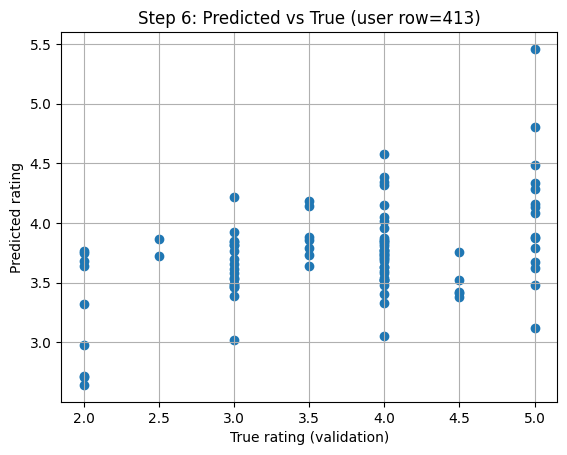

In [21]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def center_columns(X):
    mu = X.mean(axis=0, keepdims=True)
    return X - mu, mu

def svd_reconstruct_rank_k(X, k):
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    Uk = U[:, :k]
    Sk = S[:k]
    Vtk = Vt[:k, :]
    return (Uk * Sk) @ Vtk

def pca_cov_reconstruct(X, k):
    Xc, mu = center_columns(X)
    n_users = Xc.shape[0]
    Cov = (Xc.T @ Xc) / (n_users - 1)
    eigvals, eigvecs = np.linalg.eigh(Cov)
    idx = np.argsort(eigvals)[::-1]
    W = eigvecs[:, idx]
    Wk = W[:, :k]
    Xc_hat = (Xc @ Wk) @ Wk.T
    return Xc_hat + mu

def pca_svd_reconstruct(X, k):
    Xc, mu = center_columns(X)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    Uk = U[:, :k]
    Sk = S[:k]
    Vtk = Vt[:k, :]
    Xc_hat = (Uk * Sk) @ Vtk
    return Xc_hat + mu


val_counts = np.bincount(rows, minlength=A.shape[0])
u_star = int(np.argmax(val_counts))
print("Chosen user row index:", u_star)
print("Validation count for this user:", int(val_counts[u_star]))

def build_pred_matrix(best_model_name, k_best, A_fill0, A_fillmean):
    if best_model_name == "SVD + fill(0)":
        return svd_reconstruct_rank_k(A_fill0, k_best)
    elif best_model_name == "SVD + fill(mean-user)":
        return svd_reconstruct_rank_k(A_fillmean, k_best)
    elif best_model_name == "PCA(cov) + fill(0)":
        return pca_cov_reconstruct(A_fill0, k_best)
    elif best_model_name == "PCA(cov) + fill(mean-user)":
        return pca_cov_reconstruct(A_fillmean, k_best)
    elif best_model_name == "PCA(SVD) + fill(0)":
        return pca_svd_reconstruct(A_fill0, k_best)
    elif best_model_name == "PCA(SVD) + fill(mean-user)":
        return pca_svd_reconstruct(A_fillmean, k_best)
    else:
        raise ValueError("Unknown best_model_name: " + str(best_model_name))

A_pred = build_pred_matrix(best_model_name, overall_k_best, A_fill0, A_fillmean)

seen_mask = (A[u_star, :] != 0)
unseen_cols = np.where(~seen_mask)[0]

unseen_scores = A_pred[u_star, unseen_cols]
topN = 10
top_idx_local = np.argsort(unseen_scores)[::-1][:topN]
top_movie_cols = unseen_cols[top_idx_local]
top_scores = unseen_scores[top_idx_local]

movie_ids = A_mv.columns.to_numpy()

print("\nTop-10 Recommendations:")
for col, score in zip(top_movie_cols, top_scores):
    movie_id = int(movie_ids[col])
    title = md.get(movie_id, "(title not found)")
    print(f"movieId={movie_id:6d}  pred={float(score):.3f}  | {title}")

user_val_pos = np.where(rows == u_star)[0]
user_val_cols = cols[user_val_pos]

y_true_user = y_val_true[user_val_pos]
y_pred_user = A_pred[u_star, user_val_cols]

print("\nUser validation RMSE:",
      float(rmse(y_true_user, y_pred_user)))

plt.figure()
plt.scatter(y_true_user, y_pred_user)
plt.xlabel("True rating (validation)")
plt.ylabel("Predicted rating")
plt.title(f"Step 6: Predicted vs True (user row={u_star})")
plt.grid(True)
plt.show()



Step 7 — Top +10 movies (largest positive PC1 weights):
movieId=    54  w=+0.034210  | Net; The (1995)
movieId=   120  w=+0.034063  | Coneheads (1993)
movieId=   118  w=+0.033842  | City Slickers II: The Legend of Curly's Gold (1994)
movieId=   189  w=+0.033817  | Nutty Professor; The (1996)
movieId=    44  w=+0.033738  | Casper (1995)
movieId=   653  w=+0.033673  | Hollow Man (2000)
movieId=    51  w=+0.033576  | Johnny Mnemonic (1995)
movieId=   119  w=+0.033570  | Cliffhanger (1993)
movieId=    88  w=+0.033559  | Santa Clause; The (1994)
movieId=   125  w=+0.033557  | Free Willy (1993)

Step 7 — Top -10 movies (most negative PC1 weights):
movieId=    89  w=+0.027162  | Shawshank Redemption; The (1994)
movieId=   103  w=+0.027219  | Forrest Gump (1994)
movieId=   548  w=+0.027315  | American Beauty (1999)
movieId=   294  w=+0.027368  | Shining; The (1980)
movieId=    83  w=+0.027399  | Pulp Fiction (1994)
movieId=   355  w=+0.027682  | Fifth Element; The (1997)
movieId=   140  w=+0.

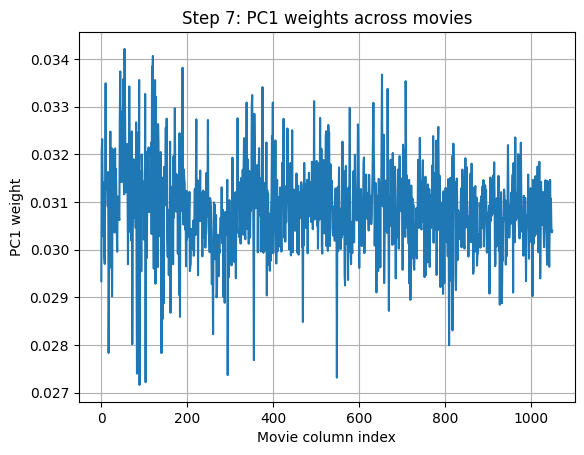

In [22]:
def center_columns(X):
    mu = X.mean(axis=0, keepdims=True)
    return X - mu, mu

X = A_fillmean.astype(np.float32)

Xc, mu = center_columns(X)

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

pc1 = Vt[0, :]   # shape: (n_movies,)

movie_ids = A_mv.columns.to_numpy()

topK = 10
pos_cols = np.argsort(pc1)[::-1][:topK]
neg_cols = np.argsort(pc1)[:topK]

print("\nStep 7 — Top +10 movies (largest positive PC1 weights):")
for col in pos_cols:
    movie_id = int(movie_ids[col])
    title = md.get(movie_id, "(title not found)")
    print(f"movieId={movie_id:6d}  w={float(pc1[col]):+.6f}  | {title}")

print("\nStep 7 — Top -10 movies (most negative PC1 weights):")
for col in neg_cols:
    movie_id = int(movie_ids[col])
    title = md.get(movie_id, "(title not found)")
    print(f"movieId={movie_id:6d}  w={float(pc1[col]):+.6f}  | {title}")

plt.figure()
plt.plot(pc1)
plt.xlabel("Movie column index")
plt.ylabel("PC1 weight")
plt.title("Step 7: PC1 weights across movies")
plt.grid(True)
plt.show()
